In [1]:
# ==============================================================================
# SECTION 1 — Environment Setup & Global Configurations
# ==============================================================================
import os
import gc
import json
import time
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import timm

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("=== SECTION 1: System Inspection ===")
print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device   : {device}")

# Global Configuration
CONFIG = {
    "seed": 42,
    "image_size": 224,
    "batch_size": 16,
    "num_workers": 2,
    "num_classes": 2,
    "epochs_per_fraction": 3,
    "lr": 1e-4,
    "output_dir": "/kaggle/working/benchmark_results"
}

output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output Directory Created: {output_dir}")

=== SECTION 1: System Inspection ===
PyTorch Version : 2.10.0+cu128
CUDA Available  : True
Active Device   : cuda
Output Directory Created: /kaggle/working/benchmark_results


In [2]:
# ==============================================================================
# SECTION 2 — Dynamic Path Resolution & PCam Dataset
# ==============================================================================
print("=== SECTION 2: Dynamic Path Resolution ===")
input_base = Path("/kaggle/input")

# 1. Dynamically locate HDF5 Dataset Files
x_h5_matches = list(input_base.rglob("*train_x.h5"))
y_h5_matches = list(input_base.rglob("*train_y.h5"))

if not x_h5_matches or not y_h5_matches:
    raise FileNotFoundError("Could not find PCam HDF5 files (*train_x.h5 / *train_y.h5) under /kaggle/input/. Ensure 'pcam-dataset' is attached.")

X_H5_PATH = str(x_h5_matches[0])
Y_H5_PATH = str(y_h5_matches[0])
print(f"Detected X Image H5 : {X_H5_PATH}")
print(f"Detected Y Label H5 : {Y_H5_PATH}")

# 2. Dynamically locate Split Indices Directory
indices_matches = list(input_base.rglob("train_indices.pt"))

if not indices_matches:
    raise FileNotFoundError("Could not locate 'train_indices.pt' under /kaggle/input/. Ensure Pipeline 1/2 output is attached.")

INDICES_DIR = indices_matches[0].parent
print(f"Detected Indices Dir: {INDICES_DIR}")


# PCam Lazy Loading Dataset Class
class PCamLazyDataset(Dataset):
    def __init__(self, x_path, y_path, transform=None):
        self.x_path = str(x_path)
        self.y_path = str(y_path)
        self.transform = transform
        self.x_file = None
        self.y_file = None

        with h5py.File(self.x_path, 'r') as fx:
            key_x = 'x' if 'x' in fx else list(fx.keys())[0]
            self.length = len(fx[key_x])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.x_file is None:
            self.x_file = h5py.File(self.x_path, 'r')
            self.x_key = 'x' if 'x' in self.x_file else list(self.x_file.keys())[0]

        if self.y_file is None:
            self.y_file = h5py.File(self.y_path, 'r')
            self.y_key = 'y' if 'y' in self.y_file else list(self.y_file.keys())[0]

        img_np = self.x_file[self.x_key][idx]
        label = self.y_file[self.y_key][idx].ravel()[0]

        img = Image.fromarray(img_np)

        if self.transform is not None:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return img, torch.tensor(label, dtype=torch.long)

=== SECTION 2: Dynamic Path Resolution ===
Detected X Image H5 : /kaggle/input/datasets/tarequlislam8/pcam-dataset/camelyonpatch_level_2_split_train_x.h5
Detected Y Label H5 : /kaggle/input/datasets/tarequlislam8/pcam-dataset/camelyonpatch_level_2_split_train_y.h5
Detected Indices Dir: /kaggle/input/notebooks/tareq10338/baseline-vit/baseline_vit/indices


In [3]:
# ==============================================================================
# SECTION 3 — Data Transformations & Split Loading
# ==============================================================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# 1. Initialize Dataset
full_dataset = PCamLazyDataset(X_H5_PATH, Y_H5_PATH, transform=eval_transform)

# 2. Extract All Raw Labels for Stratified Subsampling
with h5py.File(Y_H5_PATH, 'r') as y_file:
    y_key = 'y' if 'y' in y_file else list(y_file.keys())[0]
    raw_labels = y_file[y_key][:]
    all_labels = np.asarray(raw_labels).ravel()

# 3. Load Saved Split Indices
try:
    train_indices = torch.load(INDICES_DIR / "train_indices.pt")
    val_indices   = torch.load(INDICES_DIR / "val_indices.pt")
    test_indices  = torch.load(INDICES_DIR / "test_indices.pt")
    
    if isinstance(train_indices, torch.Tensor): train_indices = train_indices.numpy()
    if isinstance(val_indices, torch.Tensor): val_indices = val_indices.numpy()
    if isinstance(test_indices, torch.Tensor): test_indices = test_indices.numpy()
    
    print(f"\nSuccessfully loaded split indices from: {INDICES_DIR.name}")
    print(f"Split sizes -> Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_indices)}")

except Exception as e:
    print(f"\nWARNING: Could not load saved indices ({e}). Creating fallback splits...")
    total_len = len(full_dataset)
    test_indices = np.arange(int(total_len * 0.15))
    train_indices = np.arange(int(total_len * 0.15), total_len)

# 4. Construct Benchmark Test DataLoader
test_subset = Subset(full_dataset, test_indices)
test_loader = DataLoader(
    test_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available()
)

print(f"Test DataLoader ready: {len(test_subset)} samples ({len(test_loader)} batches)")


Successfully loaded split indices from: indices
Split sizes -> Train: 16000 | Val: 2000 | Test: 2000
Test DataLoader ready: 2000 samples (125 batches)


In [4]:
# ==============================================================================
# SECTION 4 — Exact Model Loader & Evaluation Routines
# ==============================================================================
def load_model(arch_name, checkpoint_path):
    """
    Instantiates model architecture and safely loads weights directly from explicit path.
    """
    model = timm.create_model(arch_name, pretrained=False, num_classes=CONFIG["num_classes"])
    ckpt_path = Path(checkpoint_path)

    if ckpt_path.exists() and ckpt_path.is_file():
        checkpoint = torch.load(ckpt_path, map_location=device)
        
        # Unnest state dict if dictionary wrapper exists
        if isinstance(checkpoint, dict):
            for k in ["encoder_state_dict", "model_state_dict", "state_dict", "model"]:
                if k in checkpoint:
                    checkpoint = checkpoint[k]
                    break

        # Strip prefixes added by wrapper modules (backbone., encoder., module.)
        cleaned_state_dict = {}
        if isinstance(checkpoint, dict):
            for key, val in checkpoint.items():
                new_key = key
                for prefix in ["backbone.", "encoder.", "module.", "model."]:
                    if new_key.startswith(prefix):
                        new_key = new_key[len(prefix):]
                cleaned_state_dict[new_key] = val
        else:
            cleaned_state_dict = checkpoint

        # Load weights
        missing_keys, unexpected_keys = model.load_state_dict(cleaned_state_dict, strict=False)
        print(f" Successfully loaded checkpoint: {ckpt_path.name}")
    else:
        print(f" WARNING: Checkpoint NOT found at: {checkpoint_path}! Running with initialized weights.")

    return model.to(device)

def evaluate_model(model, data_loader):
    """
    Evaluates model on data loader and returns metrics.
    """
    model.eval()
    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for imgs, lbls in data_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(lbls.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="binary")
    auc = roc_auc_score(all_targets, all_probs)

    return acc, f1, auc

In [5]:
from pathlib import Path
print("\n".join(str(p) for p in Path("/kaggle/input").rglob("*.pth")))

/kaggle/input/notebooks/tareq10338/baseline-vit/baseline_vit/checkpoints/best_baseline_vit.pth
/kaggle/input/notebooks/tareq10338/pipeline-2/pipeline2_contrastive_vit/checkpoints/contrastive_vit_pretrained.pth
/kaggle/input/notebooks/tareq10338/pipeline-2/pipeline2_contrastive_vit/checkpoints/best_contrastive_finetuned_vit.pth


In [6]:
# ==============================================================================
# SECTION 5 — Benchmark Loop with Explicit Checkpoint Paths
# ==============================================================================
FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]

# Direct Mapping to available checkpoints
MODELS_TO_BENCHMARK = {
    "Baseline ViT": {
        "arch": "vit_tiny_patch16_224",
        "ckpt_path": "/kaggle/input/notebooks/tareq10338/baseline-vit/baseline_vit/checkpoints/best_baseline_vit.pth"
    },
    "Contrastive Pretrained ViT": {
        "arch": "vit_tiny_patch16_224",
        "ckpt_path": "/kaggle/input/notebooks/tareq10338/pipeline-2/pipeline2_contrastive_vit/checkpoints/contrastive_vit_pretrained.pth"
    },
    "Contrastive Finetuned ViT": {
        "arch": "vit_tiny_patch16_224",
        "ckpt_path": "/kaggle/input/notebooks/tareq10338/pipeline-2/pipeline2_contrastive_vit/checkpoints/best_contrastive_finetuned_vit.pth"
    }
}

benchmark_results = []

train_pool_indices = train_indices
train_pool_labels = all_labels[train_pool_indices]

print("\n=== STARTING DATA EFFICIENCY BENCHMARK ===")

for model_name, cfg in MODELS_TO_BENCHMARK.items():
    print(f"\n--------------------------------------------------")
    print(f" Benchmarking Model: {model_name}")
    print(f" Path: {cfg['ckpt_path']}")
    print(f"--------------------------------------------------")
    
    for frac in FRACTIONS:
        # Stratified sampling of training pool
        if frac == 1.0:
            frac_indices = train_pool_indices
        else:
            n_samples = int(len(train_pool_indices) * frac)
            sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=CONFIG["seed"])
            sub_rel_idx, _ = next(sss.split(train_pool_indices, train_pool_labels))
            frac_indices = train_pool_indices[sub_rel_idx]
            
        frac_subset = Subset(full_dataset, frac_indices)
        frac_loader = DataLoader(
            frac_subset, 
            batch_size=CONFIG["batch_size"], 
            shuffle=True, 
            num_workers=CONFIG["num_workers"],
            pin_memory=torch.cuda.is_available()
        )

        # Instantiate Model & Load Weights directly from file
        model = load_model(cfg["arch"], cfg["ckpt_path"])
        optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"])
        criterion = nn.CrossEntropyLoss()

        # Fine-tune on fraction subset
        start_time = time.time()
        for epoch in range(CONFIG["epochs_per_fraction"]):
            model.train()
            for imgs, lbls in frac_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                loss.backward()
                optimizer.step()
                
        elapsed_time = time.time() - start_time

        # Evaluate on fixed test set
        acc, f1, auc = evaluate_model(model, test_loader)
        
        print(f"Label Fraction: {int(frac*100):3d}% ({len(frac_indices):5d} samples) | Test Acc: {acc:.4f} | Test F1: {f1:.4f} | Test AUC: {auc:.4f} | Time: {elapsed_time:.1f}s")

        benchmark_results.append({
            "Model": model_name,
            "Fraction": frac,
            "Label_Percentage": f"{int(frac*100)}%",
            "Samples": len(frac_indices),
            "Accuracy": round(acc, 4),
            "F1_Score": round(f1, 4),
            "ROC_AUC": round(auc, 4),
            "Time_Sec": round(elapsed_time, 2)
        })

# Save results summary to CSV
df_results = pd.DataFrame(benchmark_results)
df_results.to_csv(output_dir / "benchmark_summary.csv", index=False)
print("\n=== BENCHMARK COMPLETE — Results saved to benchmark_summary.csv ===")


=== STARTING DATA EFFICIENCY BENCHMARK ===

--------------------------------------------------
 Benchmarking Model: Baseline ViT
 Path: /kaggle/input/notebooks/tareq10338/baseline-vit/baseline_vit/checkpoints/best_baseline_vit.pth
--------------------------------------------------
 Successfully loaded checkpoint: best_baseline_vit.pth
Label Fraction:  10% ( 1600 samples) | Test Acc: 0.9410 | Test F1: 0.9385 | Test AUC: 0.9824 | Time: 31.2s
 Successfully loaded checkpoint: best_baseline_vit.pth
Label Fraction:  25% ( 4000 samples) | Test Acc: 0.9520 | Test F1: 0.9518 | Test AUC: 0.9851 | Time: 63.0s
 Successfully loaded checkpoint: best_baseline_vit.pth
Label Fraction:  50% ( 8000 samples) | Test Acc: 0.9410 | Test F1: 0.9419 | Test AUC: 0.9829 | Time: 108.3s
 Successfully loaded checkpoint: best_baseline_vit.pth
Label Fraction:  75% (12000 samples) | Test Acc: 0.9515 | Test F1: 0.9521 | Test AUC: 0.9884 | Time: 155.2s
 Successfully loaded checkpoint: best_baseline_vit.pth
Label Fracti

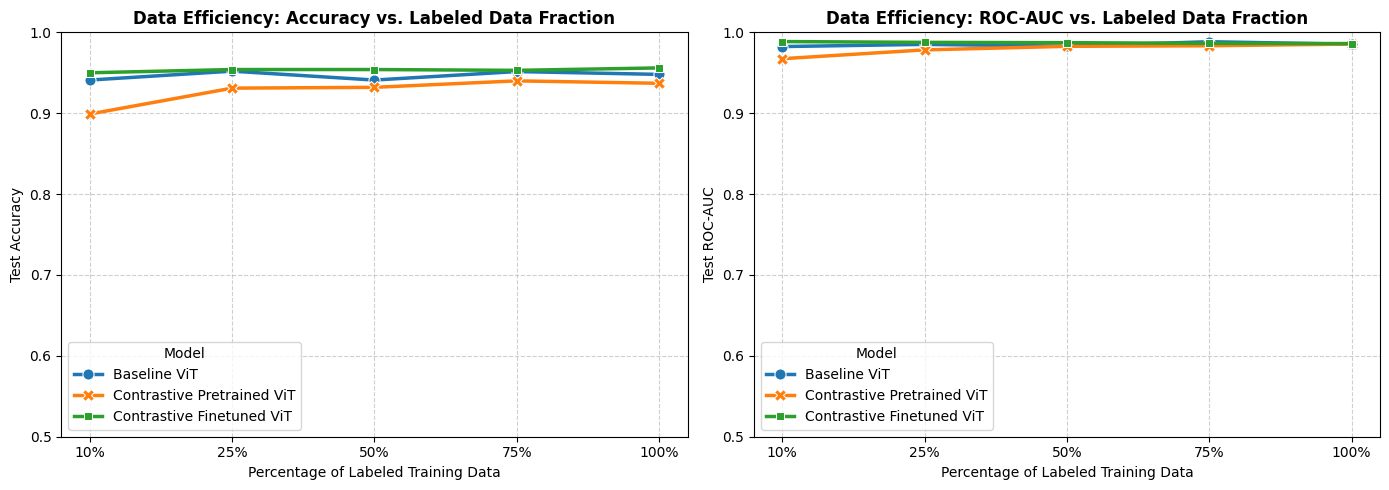


=== FINAL BENCHMARK COMPARISON TABLE ===
                     Model  Fraction Label_Percentage  Samples  Accuracy  F1_Score  ROC_AUC  Time_Sec
              Baseline ViT      0.10              10%     1600    0.9410    0.9385   0.9824     31.23
              Baseline ViT      0.25              25%     4000    0.9520    0.9518   0.9851     62.98
              Baseline ViT      0.50              50%     8000    0.9410    0.9419   0.9829    108.34
              Baseline ViT      0.75              75%    12000    0.9515    0.9521   0.9884    155.19
              Baseline ViT      1.00             100%    16000    0.9480    0.9489   0.9853    199.60
Contrastive Pretrained ViT      0.10              10%     1600    0.8990    0.8933   0.9674     29.16
Contrastive Pretrained ViT      0.25              25%     4000    0.9310    0.9292   0.9783     63.89
Contrastive Pretrained ViT      0.50              50%     8000    0.9320    0.9331   0.9827    109.81
Contrastive Pretrained ViT      0.75    

In [7]:
# ==============================================================================
# SECTION 6 — Visualizations & Benchmark Plots
# ==============================================================================
plt.figure(figsize=(14, 5))

# Plot 1: Test Accuracy vs Label Fraction
plt.subplot(1, 2, 1)
sns.lineplot(
    data=df_results,
    x="Label_Percentage",
    y="Accuracy",
    hue="Model",
    style="Model",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=8
)
plt.title("Data Efficiency: Accuracy vs. Labeled Data Fraction", fontsize=12, fontweight="bold")
plt.xlabel("Percentage of Labeled Training Data", fontsize=10)
plt.ylabel("Test Accuracy", fontsize=10)
plt.ylim(0.50, 1.00)
plt.grid(True, linestyle="--", alpha=0.6)

# Plot 2: Test ROC-AUC vs Label Fraction
plt.subplot(1, 2, 2)
sns.lineplot(
    data=df_results,
    x="Label_Percentage",
    y="ROC_AUC",
    hue="Model",
    style="Model",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=8
)
plt.title("Data Efficiency: ROC-AUC vs. Labeled Data Fraction", fontsize=12, fontweight="bold")
plt.xlabel("Percentage of Labeled Training Data", fontsize=10)
plt.ylabel("Test ROC-AUC", fontsize=10)
plt.ylim(0.50, 1.00)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(output_dir / "data_efficiency_benchmark.png", dpi=300)
plt.show()

# Print Summary Table
print("\n=== FINAL BENCHMARK COMPARISON TABLE ===")
print(df_results.to_string(index=False))